<a href="https://colab.research.google.com/github/birolcabukusta/Tools/blob/main/FFAT_score_calculate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FFAT MOTIF ANALYZER

Paste your amino acid sequence to analyze your FFAT and FFNT motif.
* One protein at a time.
* If query_sequence is filled, uses that; otherwise takes Uniprot_ID.





In [12]:
import numpy as np
import pandas as pd
#@title Input protein sequence(s), then hit `Runtime` -> `Run all`

query_sequence = '' #@param {type:"string"}
query_sequence = "".join(query_sequence.split())

Uniprot_ID = 'A6NC98; O94855; P20340; P53992;P81605;Q00765;\t Q5HYI8;Q8IXJ6;Q8TCU4;Q8TF72;Q96MG8;Q9H3P7;Q9H8Y8;Q9NR31;Q9NZT1;\t Q9Y6B6' #@param {type:"string"}


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Define scoring tables
# ------------------------------
scores_FFAT = pd.DataFrame({
    'Ideal': ["A","C","D","E","F","G","H","I","K","L","M","N","P","Q","R","S","T","V","W","Y","X"],
    'p1': [1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.5,1.0,1.0,1.0,1.0,1.0,2.0,0.5,0.5,1.0,1.0,1.0,2.0],
    'p2': [4,4,4,4,0,4,4,4,4,4,4,4,4,4,4,4,4,4,2,0,4],
    'p3': [1.0,1.0,1.0,1.0,0.0,1.0,0.7,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.5,1.0,0.7,0.5,2.0],
    'p4': [2.0,2.0,0.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.5,0.5,2.0,2.0,2.0,2.0],
    'p5': [0.0,0.0,4.0,4.0,2.0,1.0,2.0,2.0,2.5,2.0,2.0,2.0,2.0,2.0,3.0,0.5,0.5,2.0,2.0,2.0,2.0],
    'p6': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2],
    'p7': [1.0,1.0,0.0,0.0,1.0,1.0,1.5,1.0,1.5,1.0,1.0,1.0,1.0,1.0,1.5,0.5,0.5,1.0,1.0,1.0,2.0]
})

scores_FFNT = pd.DataFrame({
    'Ideal': ["A","C","D","E","F","G","H","I","K","L","M","N","P","Q","R","S","T","V","W","Y","X"],
    'p1': [1,  1,  0, 0.5,  1,  1,  1,  1, 1.5, 1,  1, .5,  1,  1,  2,  0, 0.5,  1,  1,  1,  2],
    'p2': [4,  4,  4,  4,  0,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  2,  0,  4],
    'p3': [1,  0,  1,  1,  0,  1,  1,  1,  1, .5,  1,  1,  1,  1,  1,  1,  1,  1,  1,  0,  2],
    'p4': [.5, 2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  0,  2,  2,  0, .5,  2,  2,  2,  2],
    'p5': [.5, 1,  4,  4,  2,  1,  2,  2, 2.5, 2,  2,  0,  2,  2,  3,  0 , 0  ,2,  2,  2,  2],
    'p6': [.5,.5, .5, .5, .5, .5, .5, .5, .5, .5, .5, .5,  0, .5, .5, .5, .5, .5, .5, .5,  2],
    'p7': [0,  1,  4,  4,  1,  0,  1,  1, 1.5, 1,  1, .5,  1,  1, 1.5, 0, .5,  1,  1,  1,  2]
})



acidic_values = np.arange(-8, 8.5, 0.5)  # Generates values from -8 to 8 with a step of 0.5


# Matching the length of the 'endScore' list with the length of 'acidicValue'
end_scores = [1.5] * 20 + [1] * 2 + [0.5] * 2 + [0] * 9

# Now both lists have the same length, allowing you to create the dataframe
AcidicScores = pd.DataFrame({
    'acidicValue': acidic_values,
    'endScore': end_scores
})



# ------------------------------
# Function to compute FFAT profile
# ------------------------------
def ffat_profile_with_best(sequence):
    temp_seq = ['X']*8 + list(sequence) + ['X']*8
    all_bits = []
    motifs = []

    for ii in range(len(temp_seq) - 14):
        query_N = temp_seq[ii:ii+7]
        query_core = temp_seq[ii+7:ii+14]

        acid = (
            query_N.count('D') * 1 +
            query_N.count('E') * 1 +
            query_N.count('S') * 0.5 +
            query_N.count('T') * 0.5 +
            query_N.count('R') * -1 +
            query_N.count('K') * -1
        )
        bit_acidic = AcidicScores.loc[AcidicScores['acidicValue'] == acid, 'endScore'].values[0]

        bit_core = sum([
            scores_FFAT.loc[scores_FFAT['Ideal'] == query_core[0], 'p1'].values[0],
            scores_FFAT.loc[scores_FFAT['Ideal'] == query_core[1], 'p2'].values[0],
            scores_FFAT.loc[scores_FFAT['Ideal'] == query_core[2], 'p3'].values[0],
            scores_FFAT.loc[scores_FFAT['Ideal'] == query_core[3], 'p4'].values[0],
            scores_FFAT.loc[scores_FFAT['Ideal'] == query_core[4], 'p5'].values[0],
            scores_FFAT.loc[scores_FFAT['Ideal'] == query_core[5], 'p6'].values[0],
            scores_FFAT.loc[scores_FFAT['Ideal'] == query_core[6], 'p7'].values[0]
        ])
        all_bits.append(bit_acidic + bit_core)
        motifs.append(''.join(temp_seq[ii:ii+17]))

    best_idx = int(np.argmin(all_bits))
    best_score = all_bits[best_idx]
    best_motif = motifs[best_idx]
    return all_bits, best_idx, best_score, best_motif



# ------------------------------
# Function to compute FFAT profile
# ------------------------------
def ffnt_profile_with_best(sequence):
    temp_seq = ['X']*8 + list(sequence) + ['X']*8
    all_bits = []
    motifs = []

    for ii in range(len(temp_seq) - 14):
        query_N = temp_seq[ii:ii+7]
        query_core = temp_seq[ii+7:ii+14]


        bit_core = sum([
            scores_FFNT.loc[scores_FFNT['Ideal'] == query_core[0], 'p1'].values[0],
            scores_FFNT.loc[scores_FFNT['Ideal'] == query_core[1], 'p2'].values[0],
            scores_FFNT.loc[scores_FFNT['Ideal'] == query_core[2], 'p3'].values[0],
            scores_FFNT.loc[scores_FFNT['Ideal'] == query_core[3], 'p4'].values[0],
            scores_FFNT.loc[scores_FFNT['Ideal'] == query_core[4], 'p5'].values[0],
            scores_FFNT.loc[scores_FFNT['Ideal'] == query_core[5], 'p6'].values[0],
            scores_FFNT.loc[scores_FFNT['Ideal'] == query_core[6], 'p7'].values[0]
        ])
        all_bits.append(bit_core)
        motifs.append(''.join(temp_seq[ii:ii+17]))

    best_idx = int(np.argmin(all_bits))
    best_score = all_bits[best_idx]
    best_motif = motifs[best_idx]
    return all_bits, best_idx, best_score, best_motif



# ------------------------------
# Example run
# ------------------------------
# Use the full query_sequence from cell RT-iJfXpQu5V
# query_sequence = "MSVKEGAQRKWAALKEKLGPQDSDPTEANLESADPE..."  # <-- your protein sequence
# query_sequence = "".join(query_sequence.split()) # This line is now redundant as the input cell handles spaces






In [26]:
ffat_scores, best_idx, best_score, best_motif = ffat_profile_with_best("MSVKEGAQREFFDANEKWAALKEKLGPQDSDPTEANLESADPE")
print(f"✅ Best FFAT motif found at {best_idx}–{best_idx+17}")
print(f"Motif sequence: {best_motif}")
print(f"Score: {best_score}")



✅ Best FFAT motif found at 11–28
Motif sequence: KEGAQREFFDANEKWAA
Score: 4.5


In [27]:
import requests # Needed for fetching sequences from UniProt

if query_sequence:
    # Process the user-provided sequence
    print("Using provided query_sequence for analysis...")
    ffat_scores, best_idx, best_score, best_motif = ffat_profile_with_best(query_sequence)
elif Uniprot_ID: # query_sequence is empty, proceed with Uniprot_ID
    uniprot_ids_array = []
    if "," in Uniprot_ID:
        uniprot_ids_array = [uid.strip() for uid in Uniprot_ID.split(",")]
    elif ";" in Uniprot_ID:
        uniprot_ids_array = [uid.strip() for uid in Uniprot_ID.split(";")]
    else:
        uniprot_ids_array = [Uniprot_ID.strip()]

    # Define the helper function to fetch FASTA from UniProt
    def get_fasta_sequence_from_uniprot(uniprot_id):
        try:
            url = f"https://www.uniprot.org/uniprot/{uniprot_id}.fasta"
            response = requests.get(url)
            response.raise_for_status() # Raise an exception for HTTP errors
            lines = response.text.splitlines()
            # Skip header line which starts with '>' and join the rest
            sequence = "".join(line.strip() for line in lines if not line.startswith('>'))
            return sequence
        except requests.exceptions.RequestException as e:
            print(f"Could not fetch sequence for UniProt ID {uniprot_id}: {e}")
            return None

    # Lists to accumulate results for batch processing
    all_ffat_scores_batch = []
    all_best_idx_batch = []
    all_best_score_batch = []
    all_best_motif_batch = []

    print(f"Processing {len(uniprot_ids_array)} UniProt ID(s)...")
    for uni_id in uniprot_ids_array:
        fasta_sequence = get_fasta_sequence_from_uniprot(uni_id)
        if fasta_sequence:
            print(f"Analyzing sequence for UniProt ID: {uni_id}")
            current_ffat_scores, current_best_idx, current_best_score, current_best_motif = ffat_profile_with_best(fasta_sequence)

            all_ffat_scores_batch.append(current_ffat_scores)
            all_best_idx_batch.append(current_best_idx)
            all_best_score_batch.append(current_best_score)
            all_best_motif_batch.append(current_best_motif)
            print(f"  Best motif for {uni_id}: {current_best_motif}, Score: {current_best_score}")
        else:
            print(f"Skipping analysis for UniProt ID {uni_id} due to fetch error.")

    # For compatibility with downstream cells that expect single variables,
    # assign the results of the *last* successfully processed protein.
    # If no proteins were processed, assign defaults.
    if all_ffat_scores_batch:
        ffat_scores = all_ffat_scores_batch[-1]
        best_idx = all_best_idx_batch[-1]
        best_score = all_best_score_batch[-1]
        best_motif = all_best_motif_batch[-1]
        if len(all_ffat_scores_batch) > 1:
            print("\nNote: Only results from the last processed UniProt ID will be used for subsequent plotting/printing cells.")
    else:
        print("No UniProt sequences were successfully processed. Setting default empty results.")
        ffat_scores, best_idx, best_score, best_motif = [], -1, float('inf'), "N/A" # Default values
else:
    print("Neither query_sequence nor Uniprot_ID was provided. Please provide input in the previous cell.")
    ffat_scores, best_idx, best_score, best_motif = [], -1, float('inf'), "N/A" # Default values


Processing 16 UniProt ID(s)...
Analyzing sequence for UniProt ID: A6NC98
  Best motif for A6NC98: GKGPRLRDFLSGSLATW, Score: 3.0
Analyzing sequence for UniProt ID: O94855
  Best motif for O94855: LSAMQINSYGSGMAPPS, Score: 2.5
Analyzing sequence for UniProt ID: P20340
  Best motif for P20340: MYDSFDNTYQATIGIDF, Score: 2.5
Analyzing sequence for UniProt ID: P53992
  Best motif for P53992: YQPQQNGSFGPARGPQS, Score: 2.0
Analyzing sequence for UniProt ID: P81605
  Best motif for P81605: XMRFMTLLFLTALAGAL, Score: 3.0
Analyzing sequence for UniProt ID: Q00765
  Best motif for Q00765: VALYLVFGYGASLLCNL, Score: 4.0
Analyzing sequence for UniProt ID: Q5HYI8
  Best motif for Q5HYI8: SVKSTRAVFYNSVNGII, Score: 4.0
Analyzing sequence for UniProt ID: Q8IXJ6
  Best motif for Q8IXJ6: DLVEAHGTFYTSHCVSA, Score: 2.5
Analyzing sequence for UniProt ID: Q8TCU4
  Best motif for Q8TCU4: SISSSASSFLSSNSTFC, Score: 1.0
Analyzing sequence for UniProt ID: Q8TF72
  Best motif for Q8TF72: IGPPWHQSYHSSSSTSD, Score: 1.5

In [15]:
print(f"✅ Best FFAT motif found at {best_idx}–{best_idx+17}")
print(f"Motif sequence: {best_motif}")
print(f"Score: {best_score}")

✅ Best FFAT motif found at 70–87
Motif sequence: ELTIAGMTFTTFDLGGH
Score: 6.0


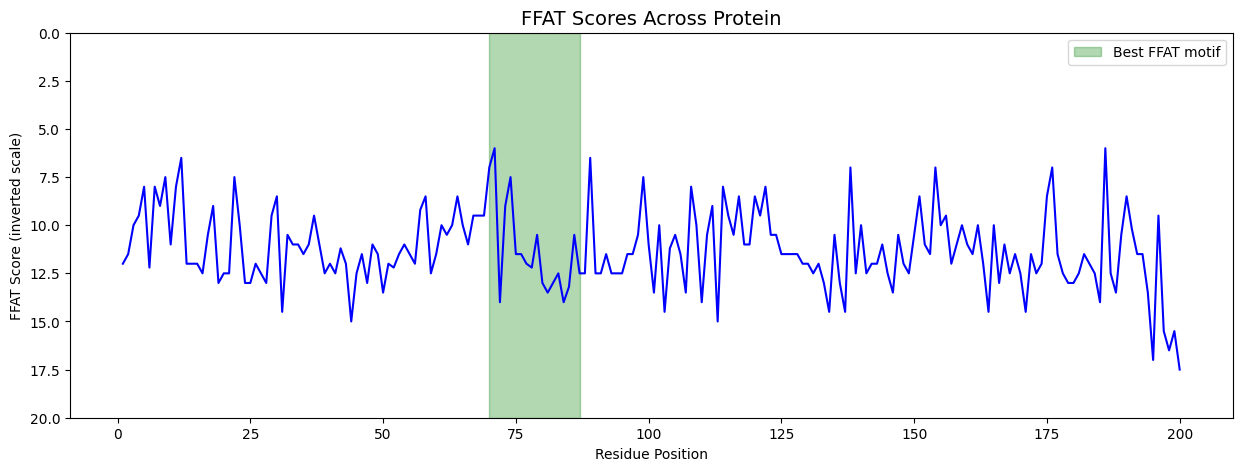

In [17]:
# ------------------------------
# Plotting
# ------------------------------
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(range(1, len(ffat_scores)+1), ffat_scores, color="blue", lw=1.5)
ax.set_title("FFAT Scores Across Protein", fontsize=14)
ax.set_xlabel("Residue Position")
ax.set_ylabel("FFAT Score (inverted scale)")
ax.set_ylim(bottom= 0, top=20)
ax.invert_yaxis()

# Red background for acidic residues, yellow for phosphorylatable residues
for i, res in enumerate(query_sequence, start=1):
    if res in ["D", "E"]:
        ax.axvspan(i-0.5, i+0.5, color="red", alpha=0.2)
    elif res in ["S", "T", "Y"]:
        ax.axvspan(i-0.5, i+0.5, color="yellow", alpha=0.1)

# Green highlight for best motif
ax.axvspan(best_idx, best_idx+17, color="green", alpha=0.3, label="Best FFAT motif")
ax.legend()

plt.show()

In [18]:
# ------------------------------
# Print the 10 best (lowest) FFAT scores
# ------------------------------

# Create list of (index, score) pairs
score_positions = list(enumerate(ffat_scores))

# Sort by score (ascending = best first)
sorted_scores = sorted(score_positions, key=lambda x: x[1])

print("Top 10 best FFAT scores:\n")

for rank, (idx, score) in enumerate(sorted_scores[:10], start=1):

    # recover motif from padded sequence
    temp_seq = ['X']*8 + list(query_sequence) + ['X']*8
    motif = ''.join(temp_seq[idx:idx+17])

    print(f"{rank:2d}. Position: {idx:4d} | Score: {score:5.2f} | Motif: {motif}")

Top 10 best FFAT scores:

 1. Position:   70 | Score:  6.00 | Motif: 
 2. Position:  185 | Score:  6.00 | Motif: 
 3. Position:   11 | Score:  6.50 | Motif: XXXXX
 4. Position:   88 | Score:  6.50 | Motif: 
 5. Position:   69 | Score:  7.00 | Motif: 
 6. Position:  137 | Score:  7.00 | Motif: 
 7. Position:  153 | Score:  7.00 | Motif: 
 8. Position:  175 | Score:  7.00 | Motif: 
 9. Position:    8 | Score:  7.50 | Motif: XXXXXXXX
10. Position:   21 | Score:  7.50 | Motif: 
